In [ ]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

In [19]:
import xarray as xr

## open ADCP data from Equator Mix 2012 field campaign
foldername = '/data/SO3/edavenport/'
eqmix_adcp_50 = xr.open_dataset(foldername + 'ADCP_prof_50.nc')
eqmix_adcp_140 = xr.open_dataset(foldername + 'ADCP_prof_140.nc')

In [2]:
import matplotlib.pyplot as plt
import cmocean.cm as cmo

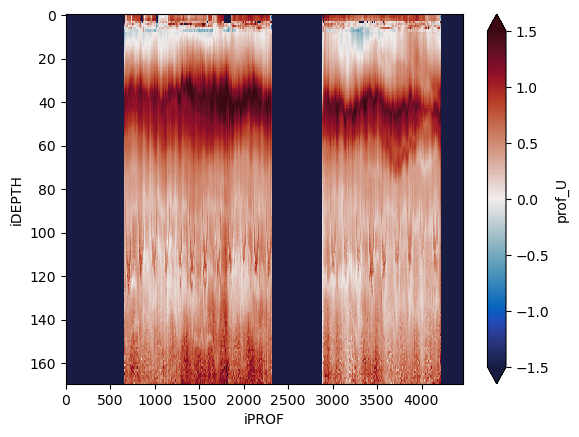

In [3]:
eqmix_adcp_140.prof_U.plot(x='iPROF',vmin=-1.5,vmax=1.5,yincrease=False,cmap=cmo.balance)

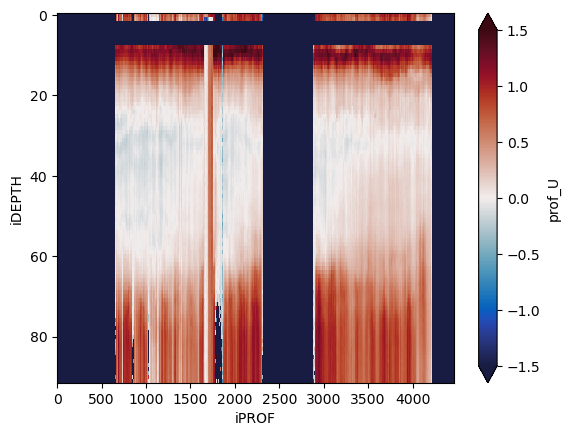

In [4]:
eqmix_adcp_50.prof_U.plot(x='iPROF',vmin=-1.5,vmax=1.5,yincrease=False,cmap=cmo.balance)

In [20]:
import pandas as pd
# Combine date and time into a datetime array
dates = eqmix_adcp_140['prof_YYYYMMDD'].values.astype(int)
times = eqmix_adcp_140['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
eqmix_adcp_140 = eqmix_adcp_140.assign_coords(time=('iPROF', datetimes))
# ds_adcp = ds_adcp.swap_dims({'iPROF': 'time'})
eqmix_adcp_140 = eqmix_adcp_140.assign_coords(depth=('iDEPTH', eqmix_adcp_140['prof_depth'].values*-1))
# ds_adcp = ds_adcp.swap_dims({'iDEPTH': 'depth'})
eqmix_adcp_140 = eqmix_adcp_140.assign_coords(lat=('iPROF', eqmix_adcp_140['prof_lat'].values))
eqmix_adcp_140 = eqmix_adcp_140.assign_coords(lon=('iPROF', eqmix_adcp_140['prof_lon'].values))

# Combine date and time into a datetime array
dates = eqmix_adcp_50['prof_YYYYMMDD'].values.astype(int)
times = eqmix_adcp_50['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
eqmix_adcp_50 = eqmix_adcp_50.assign_coords(time=('iPROF', datetimes))
# ds_adcp = ds_adcp.swap_dims({'iPROF': 'time'})
eqmix_adcp_50 = eqmix_adcp_50.assign_coords(depth=('iDEPTH', eqmix_adcp_50['prof_depth'].values*-1))
# ds_adcp = ds_adcp.swap_dims({'iDEPTH': 'depth'})
eqmix_adcp_50 = eqmix_adcp_50.assign_coords(lat=('iPROF', eqmix_adcp_50['prof_lat'].values))
eqmix_adcp_50 = eqmix_adcp_50.assign_coords(lon=('iPROF', eqmix_adcp_50['prof_lon'].values))

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2012-11-30'))
ds_tpose_TAO = ds_tpose_TAO.sel(time=slice('2012-09-01','2012-11-30'))

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [8]:
tpose_U_noTAO = ds_tpose_noTAO.UVEL.interp(time=eqmix_adcp_140.prof_U.time,YC=eqmix_adcp_140.prof_U.lat,XG=(eqmix_adcp_140.prof_U.lon + 360),Z=eqmix_adcp_140.prof_U.depth).compute().squeeze()
tpose_U_TAO = ds_tpose_TAO.UVEL.interp(time=eqmix_adcp_140.prof_U.time,YC=eqmix_adcp_140.prof_U.lat,XG=(eqmix_adcp_140.prof_U.lon + 360),Z=eqmix_adcp_140.prof_U.depth).compute().squeeze()
tpose_V_noTAO = ds_tpose_noTAO.VVEL.interp(time=eqmix_adcp_140.prof_V.time,YG=eqmix_adcp_140.prof_V.lat,XC=(eqmix_adcp_140.prof_V.lon + 360),Z=eqmix_adcp_140.prof_V.depth).compute().squeeze()
tpose_V_TAO = ds_tpose_TAO.VVEL.interp(time=eqmix_adcp_140.prof_V.time,YG=eqmix_adcp_140.prof_V.lat,XC=(eqmix_adcp_140.prof_V.lon + 360),Z=eqmix_adcp_140.prof_V.depth).compute().squeeze()

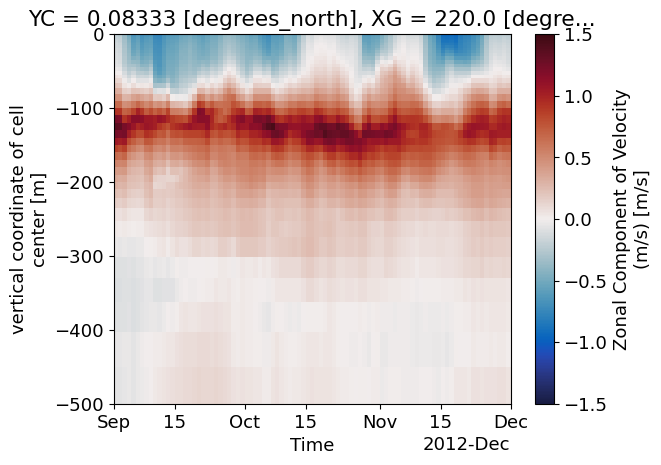

In [9]:
ds_tpose_noTAO.UVEL.sel(XG=220.0,YC=0.0,method='nearest').sel(Z=slice(0,-500)).plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance)

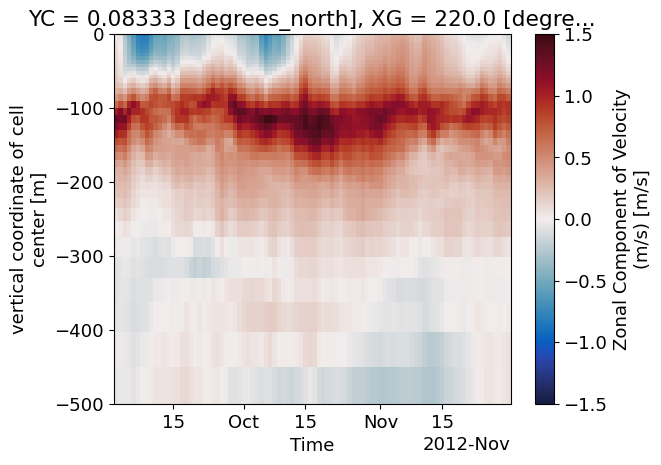

In [11]:
ds_tpose_TAO.UVEL.sel(XG=220.0,YC=0.0,method='nearest').sel(Z=slice(0,-500)).plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance)

In [15]:
tpose_U_TAO

<xarray.DataArray 'UVEL' (iPROF: 4464, iDEPTH: 170)> Size: 6MB
array([[        nan, -0.04181266, -0.03282784, ..., -0.00402764,
        -0.00396304, -0.00389845],
       [        nan, -0.04168073, -0.03270873, ..., -0.0040292 ,
        -0.00396427, -0.00389934],
       [        nan, -0.04156287, -0.03260077, ..., -0.00403263,
        -0.00396734, -0.00390205],
       ...,
       [        nan, -0.20671765, -0.19394572, ..., -0.02762584,
        -0.02763507, -0.0276443 ],
       [        nan, -0.20535297, -0.19264575, ..., -0.02747715,
        -0.02748664, -0.02749612],
       [        nan, -0.20394316, -0.19130275, ..., -0.02729037,
        -0.02730036, -0.02731034]], shape=(4464, 170))
Coordinates: (12/15)
    dyG      (iPROF) float64 36kB 1.853e+04 1.853e+04 ... 1.853e+04 1.853e+04
    dxC      (iPROF) float64 36kB 1.767e+04 1.767e+04 ... 1.842e+04 1.842e+04
    rAw      (iPROF) float64 36kB 3.274e+08 3.274e+08 ... 3.412e+08 3.412e+08
    drF      (iDEPTH) float64 1kB nan 2.0 2.0 2.0 2.358 ... 50.0 50.0 50.0 50.0
    PHrefC   (iDEPTH) float64 1kB nan 29.17 58.35 ... 4.901e+03 4.93e+03
    hFacW    (iDEPTH, iPROF) float64 6MB nan nan nan nan nan ... 1.0 1.0 1.0 1.0
    ...       ...
    YC       (iPROF) float64 36kB -17.54 -17.54 -17.54 ... -6.32 -6.347 -6.373
    XG       (iPROF) float64 36kB 210.4 210.4 210.4 210.4 ... 220.9 220.9 220.9
    Z        (iDEPTH) float64 1kB -0.0 -2.974 -5.948 ... -496.6 -499.6 -502.6
    lat      (iPROF) float64 36kB -17.54 -17.54 -17.54 ... -6.32 -6.347 -6.373
    lon      (iPROF) float64 36kB -149.6 -149.6 -149.6 ... -139.1 -139.1 -139.1
    depth    (iDEPTH) float64 1kB -0.0 -2.974 -5.948 ... -496.6 -499.6 -502.6
Dimensions without coordinates: iPROF, iDEPTH
Attributes:
    standard_name:  UVEL
    long_name:      Zonal Component of Velocity (m/s)
    units:          m/s
    mate:           VVEL

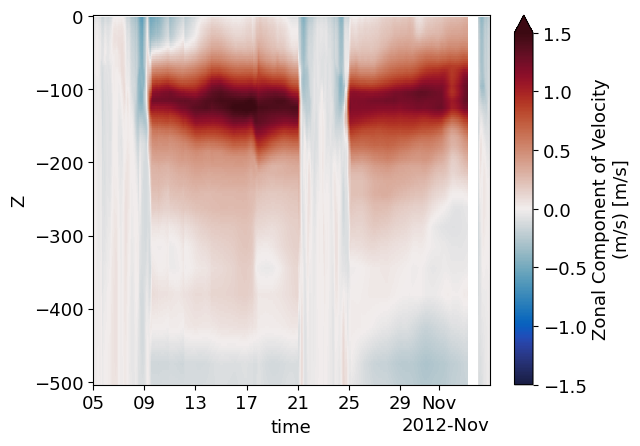

In [13]:
tpose_U_TAO.plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance)

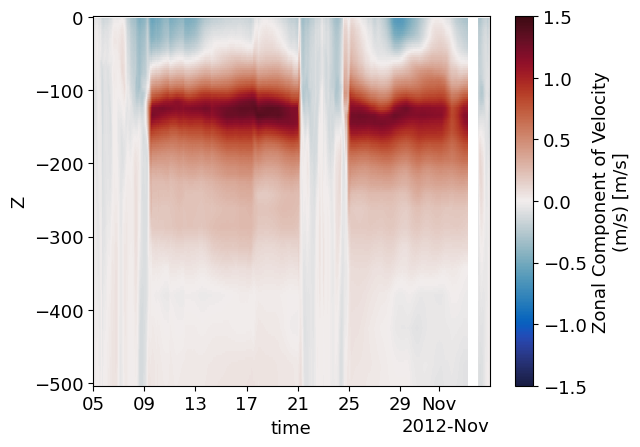

In [12]:
tpose_U_noTAO.plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance)

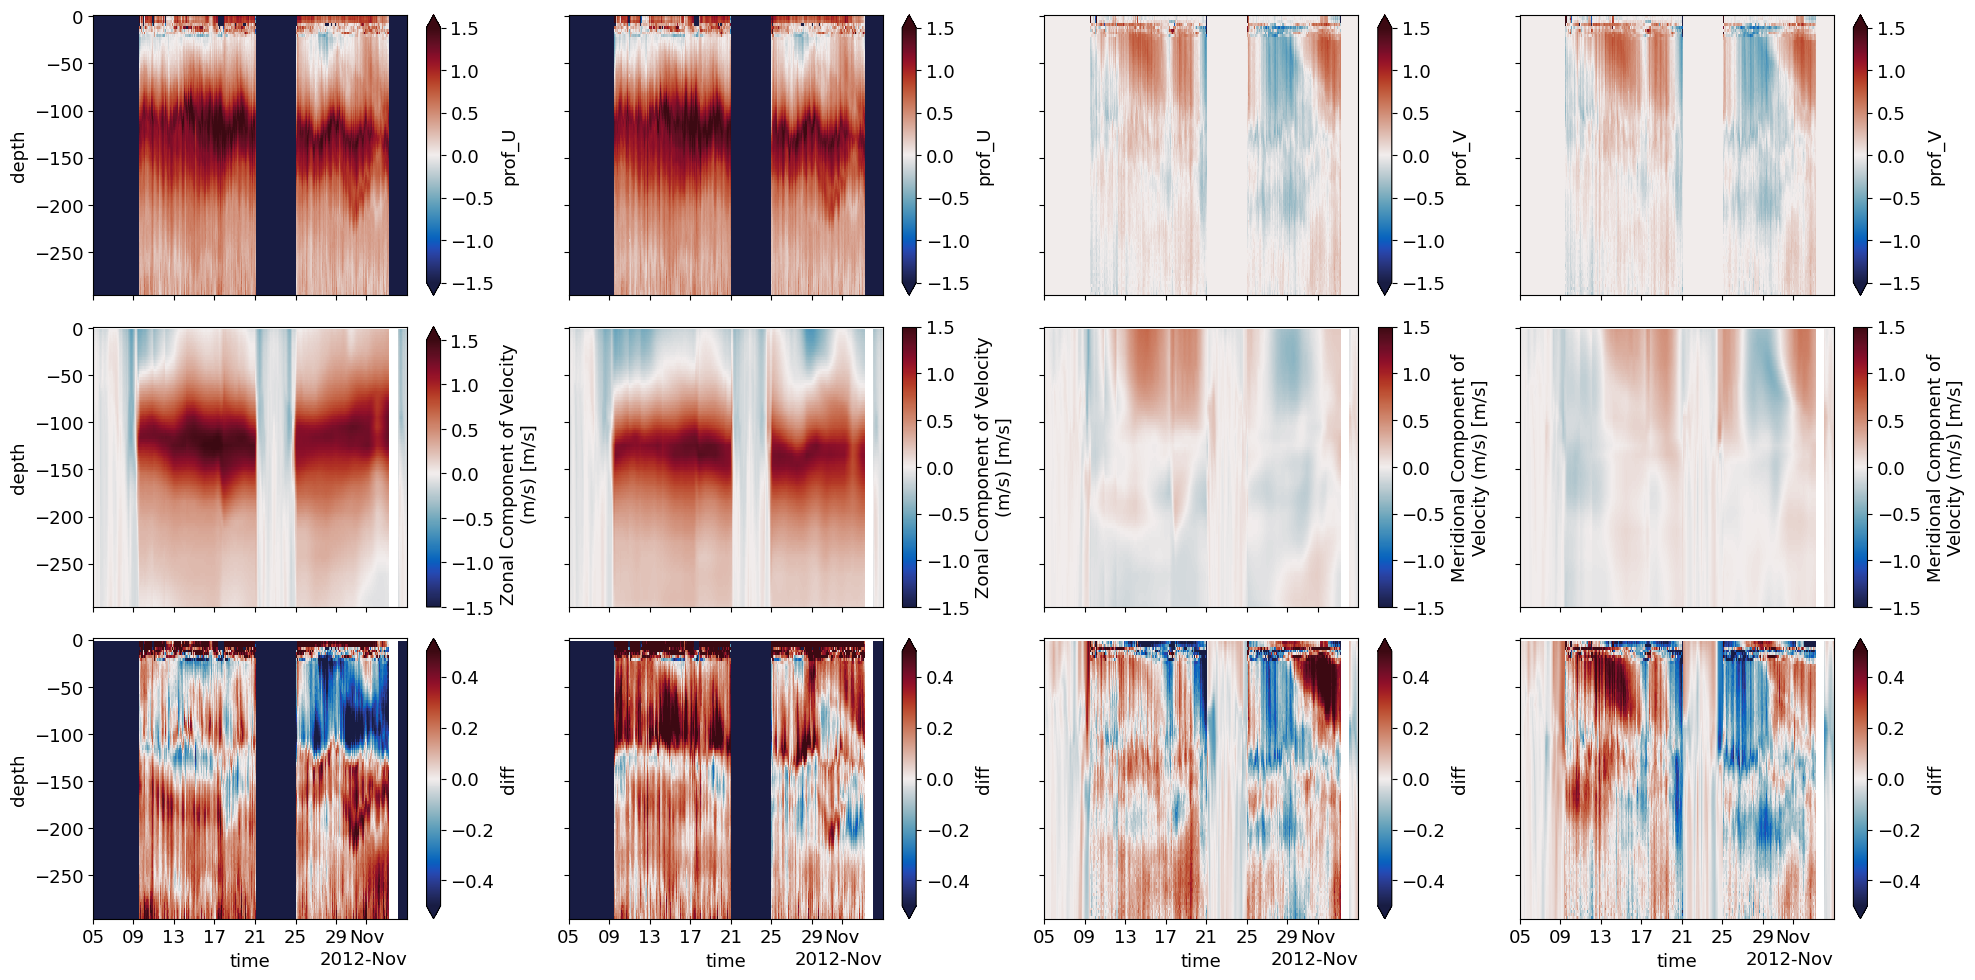

In [17]:
fig, ax = plt.subplots(figsize=(20,10),nrows=3,ncols=4,sharex=True,sharey=True)
# for each column plot (1) adcp u, (2) tpose u, (3) difference
diff = eqmix_adcp_140.prof_U.values - tpose_U_TAO.values
diff = xr.DataArray(diff,coords=tpose_U_TAO.coords,name='diff')
eqmix_adcp_140.prof_U[:,:100].plot(x='time',y='depth',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[0,0])
tpose_U_TAO[:,:100].plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[1,0])
diff[:,:100].plot(x='time',y='Z',vmin=-0.5,vmax=0.5,cmap=cmo.balance,ax=ax[2,0])

diff = eqmix_adcp_140.prof_U.values - tpose_U_noTAO.values
diff = xr.DataArray(diff,coords=tpose_U_noTAO.coords,name='diff')
eqmix_adcp_140.prof_U[:,:100].plot(x='time',y='depth',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[0,1])
tpose_U_noTAO[:,:100].plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[1,1])
diff[:,:100].plot(x='time',y='Z',vmin=-0.5,vmax=0.5,cmap=cmo.balance,ax=ax[2,1])

diff = eqmix_adcp_140.prof_V.values - tpose_V_TAO.values
diff = xr.DataArray(diff,coords=tpose_V_TAO.coords,name='diff')
eqmix_adcp_140.prof_V[:,:100].plot(x='time',y='depth',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[0,2])
tpose_V_TAO[:,:100].plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[1,2])
diff[:,:100].plot(x='time',y='Z',vmin=-0.5,vmax=0.5,cmap=cmo.balance,ax=ax[2,2])

diff = eqmix_adcp_140.prof_V.values - tpose_V_noTAO.values
diff = xr.DataArray(diff,coords=tpose_V_noTAO.coords,name='diff')
eqmix_adcp_140.prof_V[:,:100].plot(x='time',y='depth',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[0,3])
tpose_V_noTAO[:,:100].plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[1,3])
diff[:,:100].plot(x='time',y='Z',vmin=-0.5,vmax=0.5,cmap=cmo.balance,ax=ax[2,3])

for axis in ax.flatten():
    axis.set_xlabel('')
    axis.set_ylabel('')

ax[0,0].set_ylabel('depth')
ax[1,0].set_ylabel('depth')
ax[2,0].set_ylabel('depth')
ax[2,0].set_xlabel('time')
ax[2,1].set_xlabel('time')
ax[2,2].set_xlabel('time')
ax[2,3].set_xlabel('time')

plt.tight_layout()
fig.savefig('eqmix_adcp_tpose_comparison.png',dpi=300)

In [21]:
tpose_U_noTAO = ds_tpose_noTAO.UVEL.interp(time=eqmix_adcp_50.prof_U.time,YC=eqmix_adcp_50.prof_U.lat,XG=(eqmix_adcp_50.prof_U.lon + 360),Z=eqmix_adcp_50.prof_U.depth).compute().squeeze()
tpose_U_TAO = ds_tpose_TAO.UVEL.interp(time=eqmix_adcp_50.prof_U.time,YC=eqmix_adcp_50.prof_U.lat,XG=(eqmix_adcp_50.prof_U.lon + 360),Z=eqmix_adcp_50.prof_U.depth).compute().squeeze()
tpose_V_noTAO = ds_tpose_noTAO.VVEL.interp(time=eqmix_adcp_50.prof_V.time,YG=eqmix_adcp_50.prof_V.lat,XC=(eqmix_adcp_50.prof_V.lon + 360),Z=eqmix_adcp_50.prof_V.depth).compute().squeeze()
tpose_V_TAO = ds_tpose_TAO.VVEL.interp(time=eqmix_adcp_50.prof_V.time,YG=eqmix_adcp_50.prof_V.lat,XC=(eqmix_adcp_50.prof_V.lon + 360),Z=eqmix_adcp_50.prof_V.depth).compute().squeeze()

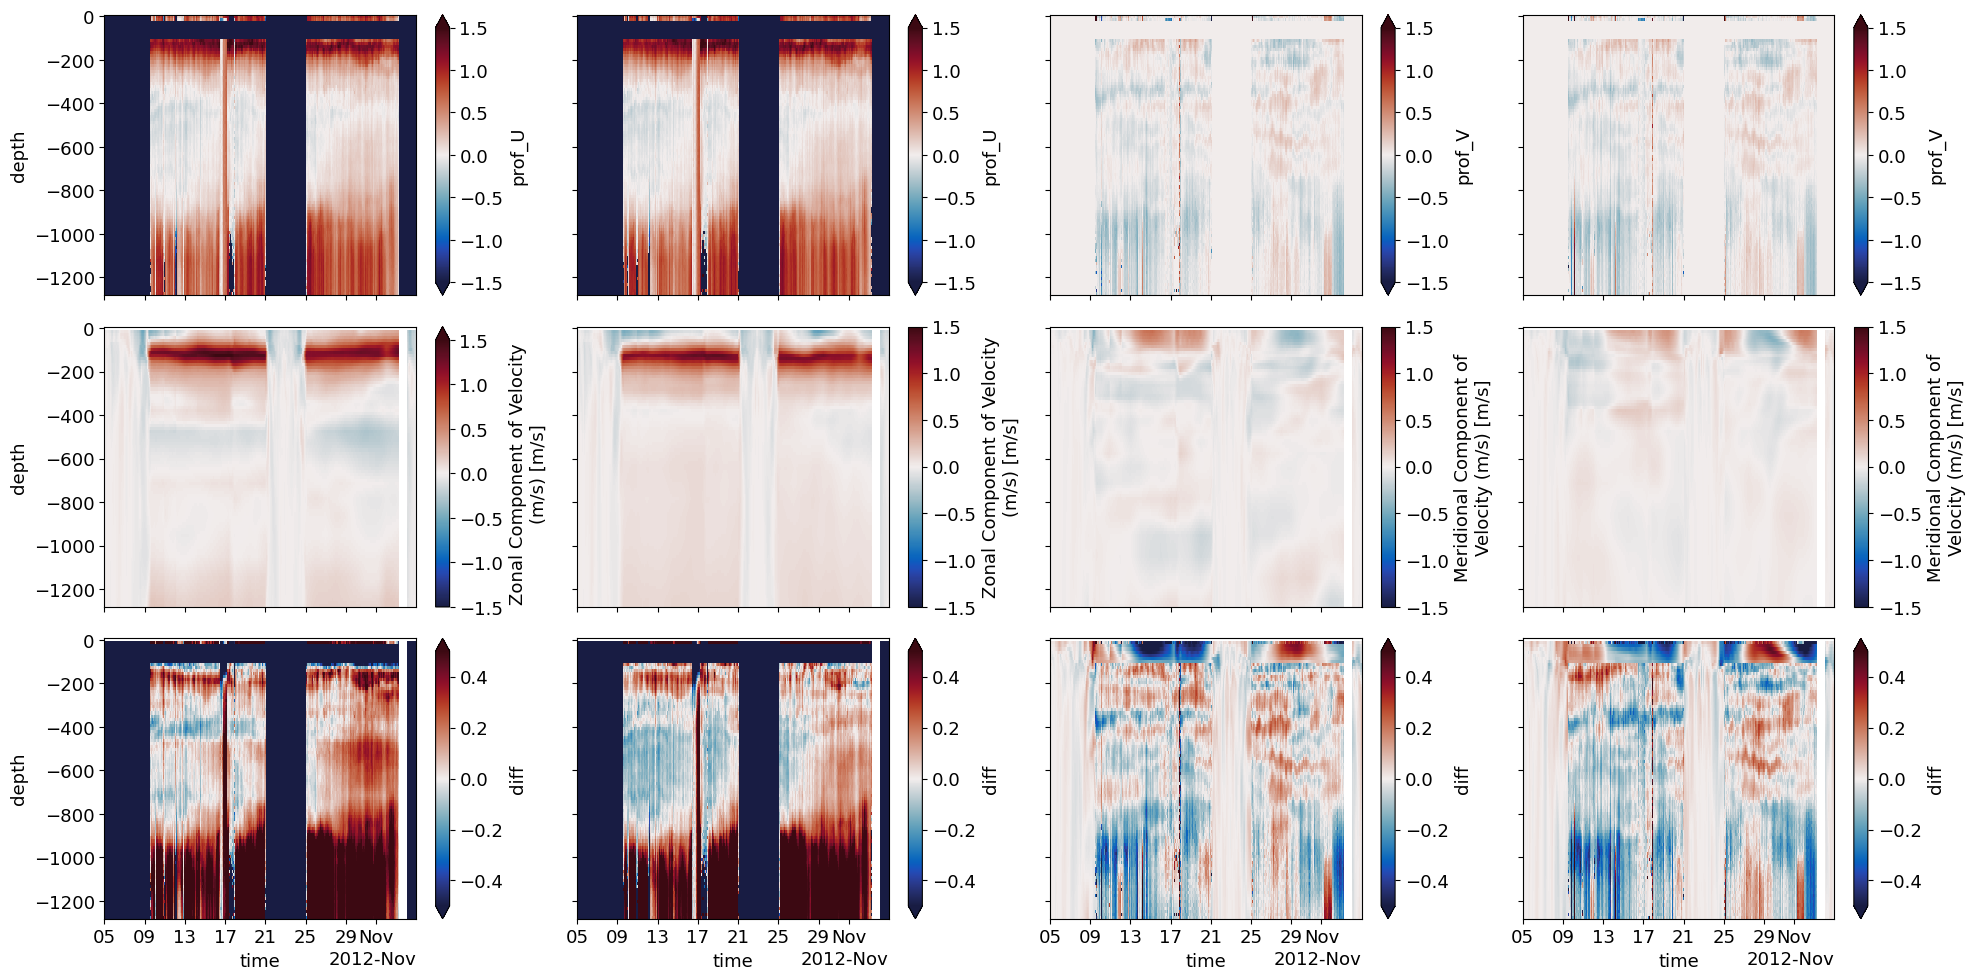

In [22]:
fig, ax = plt.subplots(figsize=(20,10),nrows=3,ncols=4,sharex=True,sharey=True)
# for each column plot (1) adcp u, (2) tpose u, (3) difference
diff = eqmix_adcp_50.prof_U.values - tpose_U_TAO.values
diff = xr.DataArray(diff,coords=tpose_U_TAO.coords,name='diff')
eqmix_adcp_50.prof_U[:,:100].plot(x='time',y='depth',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[0,0])
tpose_U_TAO[:,:100].plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[1,0])
diff[:,:100].plot(x='time',y='Z',vmin=-0.5,vmax=0.5,cmap=cmo.balance,ax=ax[2,0])

diff = eqmix_adcp_50.prof_U.values - tpose_U_noTAO.values
diff = xr.DataArray(diff,coords=tpose_U_noTAO.coords,name='diff')
eqmix_adcp_50.prof_U[:,:100].plot(x='time',y='depth',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[0,1])
tpose_U_noTAO[:,:100].plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[1,1])
diff[:,:100].plot(x='time',y='Z',vmin=-0.5,vmax=0.5,cmap=cmo.balance,ax=ax[2,1])

diff = eqmix_adcp_50.prof_V.values - tpose_V_TAO.values
diff = xr.DataArray(diff,coords=tpose_V_TAO.coords,name='diff')
eqmix_adcp_50.prof_V[:,:100].plot(x='time',y='depth',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[0,2])
tpose_V_TAO[:,:100].plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[1,2])
diff[:,:100].plot(x='time',y='Z',vmin=-0.5,vmax=0.5,cmap=cmo.balance,ax=ax[2,2])

diff = eqmix_adcp_50.prof_V.values - tpose_V_noTAO.values
diff = xr.DataArray(diff,coords=tpose_V_noTAO.coords,name='diff')
eqmix_adcp_50.prof_V[:,:100].plot(x='time',y='depth',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[0,3])
tpose_V_noTAO[:,:100].plot(x='time',y='Z',vmin=-1.5,vmax=1.5,cmap=cmo.balance,ax=ax[1,3])
diff[:,:100].plot(x='time',y='Z',vmin=-0.5,vmax=0.5,cmap=cmo.balance,ax=ax[2,3])

for axis in ax.flatten():
    axis.set_xlabel('')
    axis.set_ylabel('')

ax[0,0].set_ylabel('depth')
ax[1,0].set_ylabel('depth')
ax[2,0].set_ylabel('depth')
ax[2,0].set_xlabel('time')
ax[2,1].set_xlabel('time')
ax[2,2].set_xlabel('time')
ax[2,3].set_xlabel('time')

plt.tight_layout()
fig.savefig('eqmix_adcp_tpose_comparison_50kHz.png',dpi=300)